# TP - DLA - Privacy defense (II) - defense against Gradient Inversion

The goal of this practical session is to implement a simple defense against privacy attacks on a simple network.
In this notebook, we focus on noise injection against gradient inversion attack.

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [8]:
# =====================================================
# Parameters (easy to tweak)
# =====================================================
NOISE_STD = 0.01      # standard deviation of Gaussian noise (DP strength)
MAX_NORM = 1.0         # clipping norm
N_ITERS = 500          # number of optimization steps
LR = 0.1               # learning rate for inversion
SEED = 42              # random seed for reproducibility
# =====================================================

torch.manual_seed(SEED)


## Loading an untrained model

First, we are given an untrained model (and we select the first sample as a target for the reconstruction with its label assumed to be known).

In [9]:
# -------------------------------
# 1. Load one MNIST sample
# -------------------------------
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
x, y = train_dataset[0]   # take one sample
x = x.unsqueeze(0)
y = torch.tensor([y])

# -------------------------------
# 2. Simple untrained model
# -------------------------------
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = Net()

# -------------------------------
# 3. Compute true gradients
# -------------------------------
criterion = nn.CrossEntropyLoss()
logits = model(x)
loss = criterion(logits, y)
true_grads = torch.autograd.grad(loss, model.parameters())



#

# DP mechanism on gradients
In this defense, we will rely on a postprocessing of the gradients and we will add some gaussian noise to the scaled gradient (in practice, it is called clipping).

In [10]:
# -------------------------------
# 4. DP mechanism: clip + noise
# -------------------------------
def privatize_gradients(grads, max_norm=MAX_NORM, noise_std=NOISE_STD):
      # TODO: implement the clipping + Gaussian noise mechanism
    # 1) compute total global L2 norm across all parameter tensors
    total_norm=sum([g.norm() for g in grads])
    # 2) compute scale = max(1.0, total_norm / max_norm)
    scale=max(1.0, total_norm / max_norm)
    # 3) create clipped = [g / scale for g in grads] 
    clipped=[g / scale for g in grads]
    # 4) create noisy = [g + gaussian noise for g in clipped]
    nois_grad=[g +noise_std for g in clipped]
    # 5) return noisy gradients
    return nois_grad


dp_grads = privatize_gradients(true_grads)

# Attack with and without noise

In [11]:
# -------------------------------
# 5. Gradient inversion
# -------------------------------
def reconstruct_from_gradients(model, grads, y, iters=N_ITERS, lr=LR):
    dummy_x = torch.randn_like(x, requires_grad=True)
    optimizer = optim.Adam([dummy_x], lr=lr)
    for it in range(iters):
        optimizer.zero_grad()
        dummy_logits = model(dummy_x)
        dummy_loss = criterion(dummy_logits, y)
        dummy_grads = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)
        grad_diff = sum(((dg - tg.detach())**2).sum() for dg, tg in zip(dummy_grads, grads))
        grad_diff.backward()
        optimizer.step()
    return dummy_x.detach()

# -------------------------------
# 6. Reconstructions
# -------------------------------
recon_non_dp = reconstruct_from_gradients(model, true_grads, y)
recon_dp     = reconstruct_from_gradients(model, dp_grads, y)



# Visualization

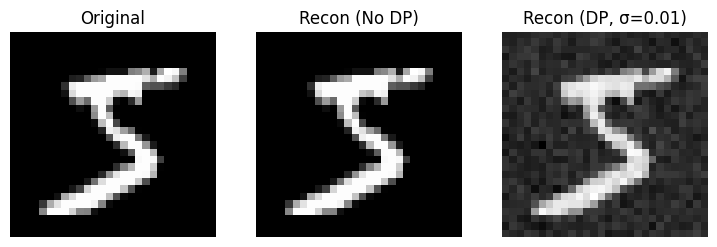

In [12]:
# -------------------------------
# 7. Visualization
# -------------------------------
fig, axs = plt.subplots(1,3, figsize=(9,3))
axs[0].imshow(x.squeeze(), cmap="gray")
axs[0].set_title("Original")
axs[0].axis("off")
axs[1].imshow(recon_non_dp.squeeze(), cmap="gray")
axs[1].set_title("Recon (No DP)")
axs[1].axis("off")
axs[2].imshow(recon_dp.squeeze(), cmap="gray")
axs[2].set_title(f"Recon (DP, σ={NOISE_STD})")
axs[2].axis("off")
plt.show()